<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/Rybchynska_Olena__%22HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [41]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [42]:
import sys
import os
path = '/content/drive/MyDrive/ML/2_5'
sys.path.append(path)
!ls drive/MyDrive/ML/3_1/

marketing_campaign.csv


In [43]:
import pandas as pd

df = pd.read_csv('drive/MyDrive/ML/3_1/marketing_campaign.csv', sep='\t')
df_original = df.copy()
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [44]:
print(f"Рядків: {df.shape[0]}, Колонок: {df.shape[1]}")
print()
print(df.dtypes)
print()
print("Пропущені значення:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df

Рядків: 2240, Колонок: 29

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Пропущені значення:
Income    24
dtype: int64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


Висновок: лише 1 колонка має пропуски - це Income, 24 пропуски

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

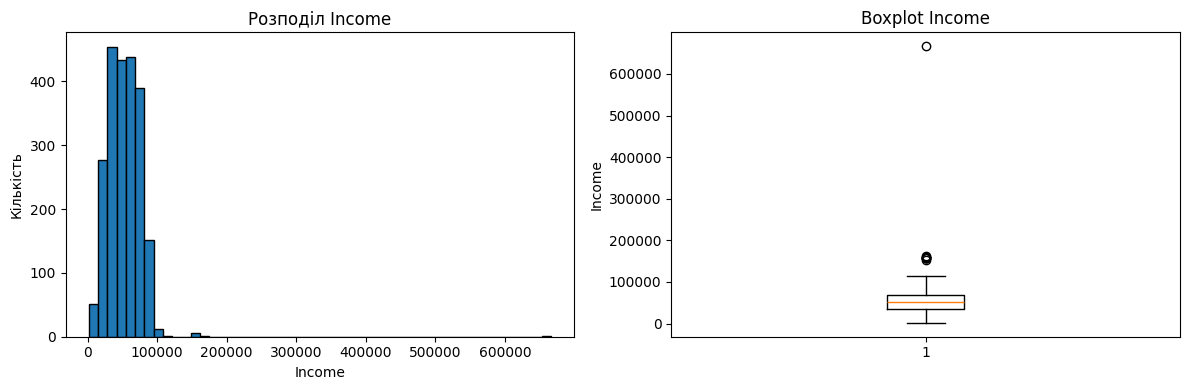

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64


In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гістограма
axes[0].hist(df['Income'].dropna(), bins=50, edgecolor='black')
axes[0].set_title('Розподіл Income')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Кількість')

# Boxplot
axes[1].boxplot(df['Income'].dropna())
axes[1].set_title('Boxplot Income')
axes[1].set_ylabel('Income')

plt.tight_layout()
plt.show()

print(df['Income'].describe())

Так як є викиди, то пропуски треба заповнювати медіаною, щоб не викривити картину по типовому клієнту

In [46]:
df['Income'] = df['Income'].fillna(df['Income'].median())

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [47]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Категоріальні колонки:", categorical_cols)
print()

Категоріальні колонки: ['Education', 'Marital_Status', 'Dt_Customer']



In [48]:
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")
    print()

Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Marital_Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

Dt_Customer: ['04-09-2012' '08-03-2014' '21-08-2013' '10-02-2014' '19-01-2014'
 '09-09-2013' '13-11-2012' '08-05-2013' '06-06-2013' '13-03-2014'
 '15-11-2013' '10-10-2012' '24-11-2012' '24-12-2012' '31-08-2012'
 '28-03-2013' '03-11-2012' '08-08-2012' '06-01-2013' '23-12-2012'
 '11-01-2014' '18-03-2013' '02-01-2013' '27-05-2013' '20-02-2013'
 '31-05-2013' '22-11-2013' '22-05-2014' '11-05-2013' '29-10-2012'
 '29-08-2013' '31-12-2013' '02-09-2013' '11-02-2014' '01-02-2013'
 '29-04-2013' '12-03-2013' '05-11-2013' '02-10-2013' '28-06-2014'
 '09-11-2012' '24-05-2013' '01-01-2014' '08-11-2012' '12-05-2014'
 '11-08-2012' '07-06-2014' '12-06-2013' '19-11-2012' '02-04-2013'
 '28-04-2014' '17-06-2013' '03-03-2014' '04-07-2013' '07-09-2012'
 '18-02-2013' '11-06-2013' '06-12-2013' '21-05-2013' '11-05-2014'
 '19-03-2014' '27-09-2013' '08-04-2013' '1

In [49]:
from sklearn.preprocessing import OrdinalEncoder

# --- Education ---
education_order = [['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']]

encoder = OrdinalEncoder(categories=education_order)
df['Education'] = encoder.fit_transform(df[['Education']])

# --- Marital_Status ---
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})
df = pd.get_dummies(df, columns=['Marital_Status'])

# --- Dt_Customer ---
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
ref_date = df['Dt_Customer'].max()
df['Days_Customer'] = (ref_date - df['Dt_Customer']).dt.days
df = df.drop(columns=['Dt_Customer'])

# Перевірка
print(df.dtypes)

ID                           int64
Year_Birth                   int64
Education                  float64
Income                     float64
Kidhome                      int64
Teenhome                     int64
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
AcceptedCmp3                 int64
AcceptedCmp4                 int64
AcceptedCmp5                 int64
AcceptedCmp1                 int64
AcceptedCmp2                 int64
Complain                     int64
Z_CostContact                int64
Z_Revenue                    int64
Response                     int64
Marital_Status_Divorced       bool
Marital_Status_Marri

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import KMeans

In [51]:
X = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Response'])

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[2 0 2 ... 2 2 2]


In [52]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.60


KMeans з k=3 дав силует 0.60, що свідчить про досить чітке розділення даних на 3 кластери. Кластери відносно компактні та добре відокремлені один від одного.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [53]:
import plotly.express as px

# Додамо загальні витрати для візуалізації
X_viz = X.copy()
X_viz['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                       X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds'])
X_viz['TotalPurchases'] = (X['NumWebPurchases'] + X['NumCatalogPurchases'] +
                           X['NumStorePurchases'])
X_viz['Cluster'] = labels.astype(str)

fig = px.scatter_3d(
    X_viz,
    x='Income',
    y='TotalSpent',
    z='TotalPurchases',
    color='Cluster',
    title='KMeans k=3: Income vs TotalSpent vs TotalPurchases',
    opacity=0.7
)
fig.show()

З 3D візуалізації (Income × TotalSpent × TotalPurchases) видно три чітко розділені групи клієнтів:

Кластер 1 (червоний) — низький дохід, низькі витрати, мала кількість покупок. Це економні клієнти, які рідко і мало купують.
Кластер 3 (синій) — середній та високий дохід, високі витрати, велика кількість покупок. Це найактивніші та найбільш платоспроможні клієнти.
Кластер 2 (зелений) — очевидний викид: один клієнт з аномально високим доходом (~666k), але відносно низькою активністю. Це той самий викид, який ми бачили ще на boxplot у Завданні 2.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaled)

labels = kmeans.predict(X_scaled)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_scaled, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.14


In [56]:
X_viz_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_viz_scaled['TotalSpent'] = (X_viz_scaled['MntWines'] + X_viz_scaled['MntFruits'] +
                               X_viz_scaled['MntMeatProducts'] + X_viz_scaled['MntFishProducts'] +
                               X_viz_scaled['MntSweetProducts'] + X_viz_scaled['MntGoldProds'])
X_viz_scaled['TotalPurchases'] = (X_viz_scaled['NumWebPurchases'] + X_viz_scaled['NumCatalogPurchases'] +
                                   X_viz_scaled['NumStorePurchases'])
X_viz_scaled['Cluster'] = labels.astype(str)

fig = px.scatter_3d(
    X_viz_scaled,
    x='Income',
    y='TotalSpent',
    z='TotalPurchases',
    color='Cluster',
    title='KMeans k=3 після StandardScaler: Income vs TotalSpent vs TotalPurchases',
    opacity=0.7
)
fig.show()

Без масштабування (Silhouette = 0.60): кластери розділились переважно за ознакою Income, оскільки вона має найбільший числовий діапазон і домінувала у розрахунку відстаней. Викид (~666k) був виділений в окремий кластер.
Після StandardScaler ( Silhouette = 0.14): всі ознаки отримали однакову вагу. На графіку видно, що кластери стали менш чіткими — точки більше перемішані. Алгоритм тепер враховує всі ознаки рівномірно, але через наявність викидів та шумових ознак (наприклад, бінарні колонки Marital_Status) загальна якість кластеризації погіршилась.


**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [57]:
print(f'Рядків до: {df.shape[0]}')

df = df[df['Income'] < 200000]

print(f'Рядків після: {df.shape[0]}')

Рядків до: 2240
Рядків після: 2239


In [58]:
X = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Response'])

З boxplot у Завданні 2 був виявлений один очевидний викид — клієнт з доходом ~666k, який значно відривається від решти даних. Цей рядок був видалений. Після очищення датасет містить 2239 записів.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

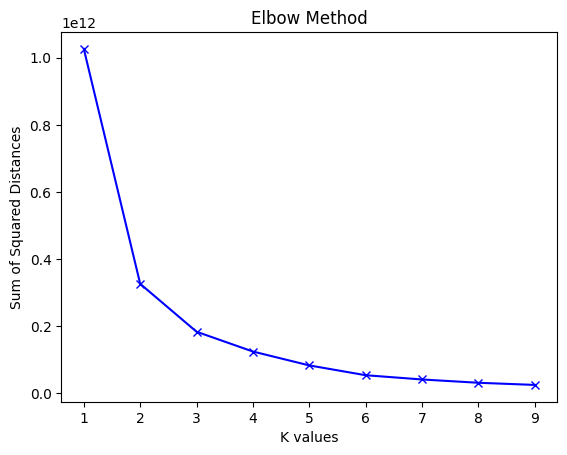

In [59]:
K = range(1, 10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto').fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

In [65]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


In [66]:
X_viz = X.copy()
X_viz['TotalSpent'] = (X['MntWines'] + X['MntFruits'] + X['MntMeatProducts'] +
                       X['MntFishProducts'] + X['MntSweetProducts'] + X['MntGoldProds'])
X_viz['TotalPurchases'] = (X['NumWebPurchases'] + X['NumCatalogPurchases'] +
                           X['NumStorePurchases'])
X_viz['Cluster'] = labels.astype(str)

fig = px.scatter_3d(
    X_viz,
    x='Income',
    y='TotalSpent',
    z='TotalPurchases',
    color='Cluster',
    title='KMeans k=3 після видалення викидів: Income vs TotalSpent vs TotalPurchases',
    opacity=0.7
)
fig.show()

З графіку методу ліктя найбільший перегин спостерігається при k=3 — після цього значення крива суттєво вирівнюється і додаткові кластери не дають значного зменшення суми квадратів відстаней. Тому оптимальним є k=3.
Після видалення викиду Silhouette знизився з 0.60 до 0.54 -це значення відображає реальну якість кластеризації.
На 3D графіку видно три змістовні групи клієнтів: клієнти з низьким доходом і низькими витратами (червоний), клієнти з середнім доходом і середньою активністю (синій), клієнти з високим доходом і високими витратами (зелений).

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

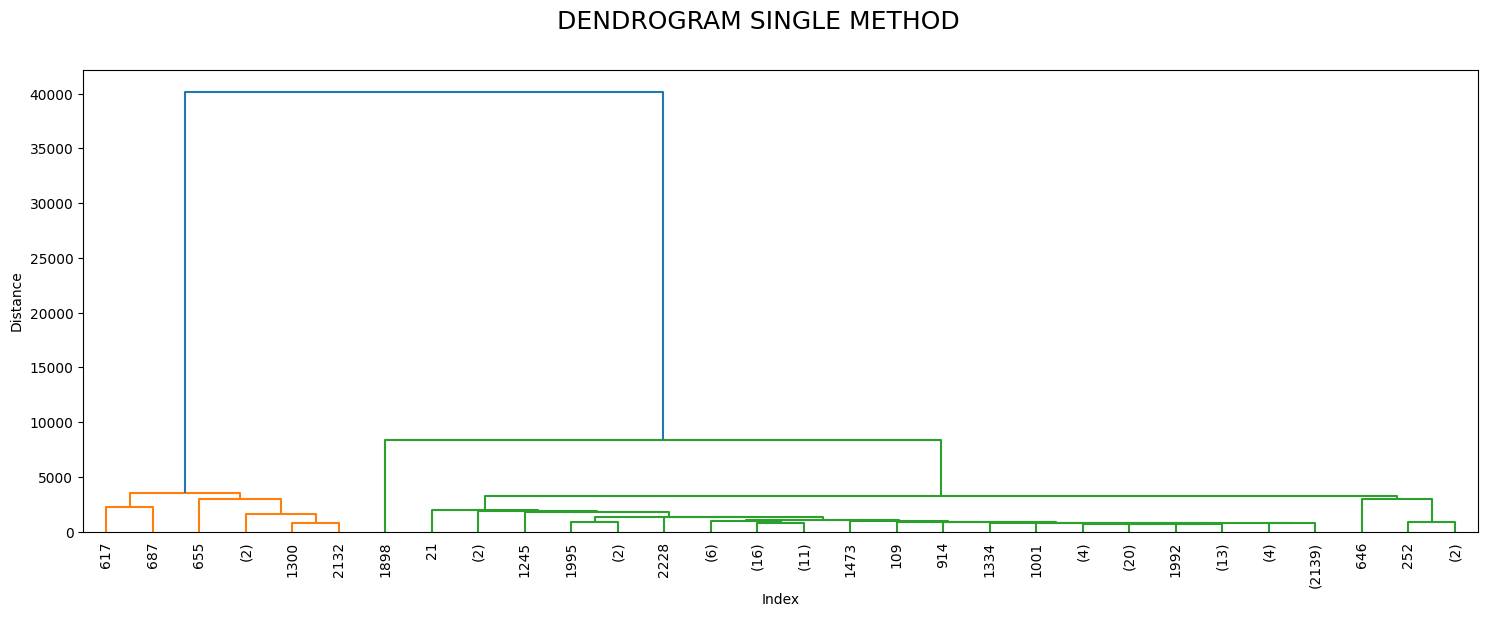

In [71]:
dist_sin = linkage(X, method="single")
plt.figure(figsize=(18, 6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp', p=30)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("DENDROGRAM SINGLE METHOD", fontsize=18)
plt.show()

Трошки уріжемо діаграму

In [72]:
df['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
df['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_Revenue,Response,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Days_Customer,2_clust,3_clust
0,5524,1957,2.0,58138.0,0,0,58,635,88,546,...,11,1,False,False,True,False,False,663,2,2
1,2174,1954,2.0,46344.0,1,1,38,11,1,6,...,11,0,False,False,True,False,False,113,2,2
2,4141,1965,2.0,71613.0,0,0,26,426,49,127,...,11,0,False,False,False,True,False,312,2,2
3,6182,1984,2.0,26646.0,1,0,26,11,4,20,...,11,0,False,False,False,True,False,139,2,2
4,5324,1981,4.0,58293.0,1,0,94,173,43,118,...,11,0,False,True,False,False,False,161,2,2


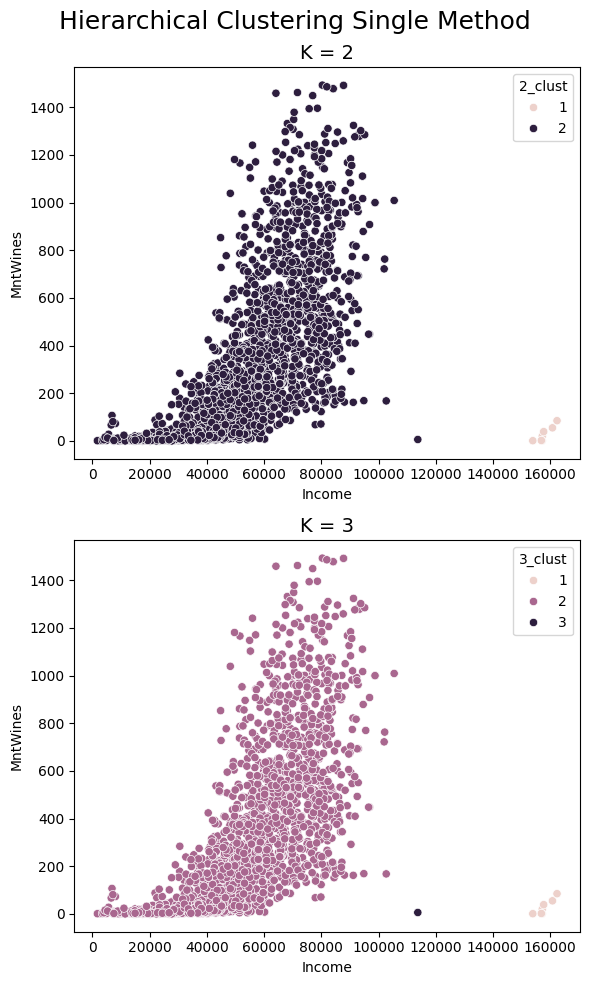

In [74]:
import seaborn as sns
plt.figure(figsize=(6, 10))

plt.suptitle("Hierarchical Clustering Single Method", fontsize=18)

plt.subplot(2, 1, 1)
plt.title("K = 2", fontsize=14)
sns.scatterplot(x="Income", y="MntWines", data=df, hue="2_clust")

plt.subplot(2, 1, 2)
plt.title("K = 3", fontsize=14)
sns.scatterplot(x="Income", y="MntWines", data=df, hue="3_clust")

plt.tight_layout()
plt.show()

In [85]:
s = metrics.silhouette_score(X, df['2_clust'], metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.77


Аналіз ієрархічної кластеризації Single linkage:
З дендрограми та scatter plot видно типовий "ланцюговий ефект" (chaining effect) методу Single linkage — майже всі точки злипаються в один великий кластер, а окремо виділяється лише невелика група з високим доходом (~130-160k) і низькою купівельною активністю.
При k=2: один кластер містить практично всі спостереження (темний), другий — лише кілька точок-викидів за доходом.
При k=3: перехід від 2 до 3 кластерів не дає змістовного розбиття — третій кластер містить лише одну точку. Це підтверджує, що Single linkage погано підходить для цього датасету через його чутливість до викидів та схильність утворювати нерівномірні кластери.

Метрика силуету для Single linkage з k=2 становить 0.77, що формально є високим значенням. Однак цей результат є оманливим — через "ланцюговий ефект" майже всі точки потрапляють в один великий щільний кластер, що автоматично дає високий силует. Реальна якість розбиття є низькою, оскільки другий кластер містить лише кілька точок і не несе змістовної інформації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Спробую метод AgglomerativeClustering

Estimated number of clusters: 3
Silhouette Coefficient for the data Dataset Clusters: 0.60


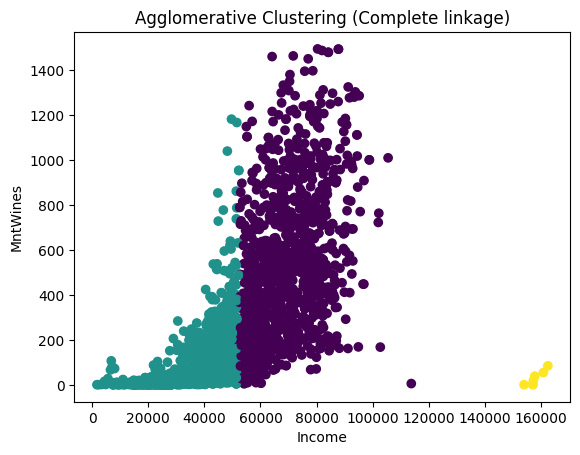

In [84]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

n_clusters_ = len(set(labels))
print('Estimated number of clusters: %d' % n_clusters_)

s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

plt.scatter(X['Income'], X['MntWines'], c=labels)
plt.xlabel('Income')
plt.ylabel('MntWines')
plt.title('Agglomerative Clustering (Complete linkage)')
plt.show()

Обрано метод AgglomerativeClustering з Complete linkage — на відміну від Single linkage, цей метод визначає відстань між кластерами як максимальну відстань між їх точками, що робить його стійкішим до "ланцюгового ефекту".
Результат з k=3 дав Silhouette = 0.60, що відповідає результату KMeans.

 На графіку чітко видно три змістовні групи:

Бірюзовий — клієнти з низьким доходом (до ~55k) і низькою купівельною активністю

Фіолетовий — клієнти з середнім та високим доходом і високою купівельною активністю

Жовтий — невелика група клієнтів з дуже високим доходом (>130k) але низькою активністю — потенційні викиди

